In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import VotingRegressor, RandomForestRegressor, AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, VotingClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, mean_absolute_error, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df=pd.read_csv("adult.csv")
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

In [2]:
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [3]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
df.replace('?',np.nan,inplace=True)

In [5]:
df["workclass"]=df["workclass"].fillna(df["workclass"].mode()[0])

In [6]:
df["occupation"]=df["occupation"].fillna(df["occupation"].mode()[0])
df["native.country"]=df["native.country"].fillna(df["native.country"].mode()[0])

In [7]:
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [8]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,77053,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,186061,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [9]:
df=pd.get_dummies(df,columns=["marital.status","relationship","sex","workclass","education","race"])
df=df.drop(columns=['native.country','occupation'])

In [10]:
df['income']=(df['income']=='<=50K').astype(int)
df.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,marital.status_Divorced,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,...,education_HS-grad,education_Masters,education_Preschool,education_Prof-school,education_Some-college,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White
0,90,77053,9,0,4356,40,1,False,False,False,...,True,False,False,False,False,False,False,False,False,True
1,82,132870,9,0,4356,18,1,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,66,186061,10,0,4356,40,1,False,False,False,...,False,False,False,False,True,False,False,True,False,False
3,54,140359,4,0,3900,40,1,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4,41,264663,10,0,3900,40,1,False,False,False,...,False,False,False,False,True,False,False,False,False,True


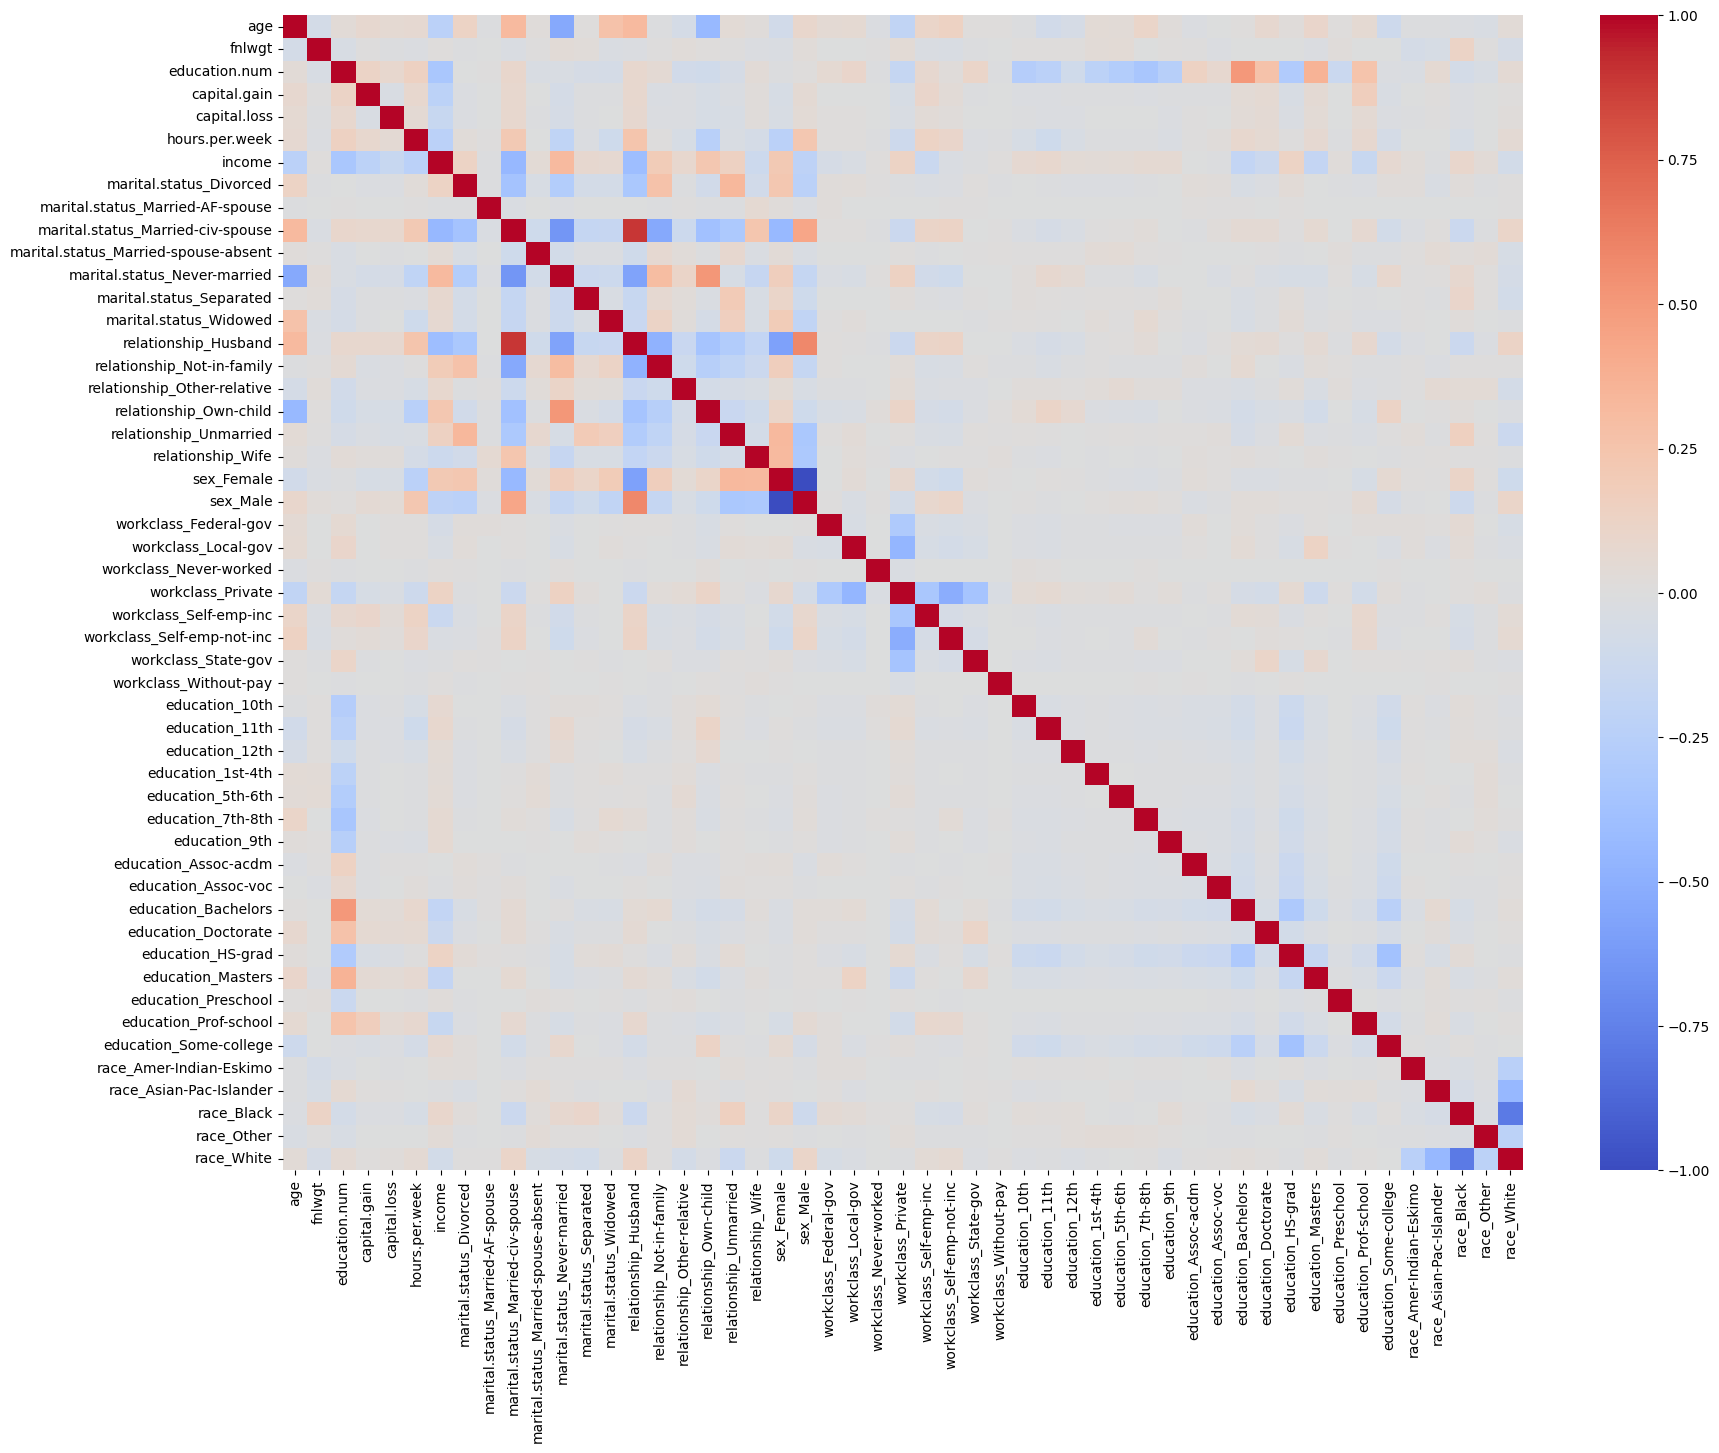

In [11]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),cmap='coolwarm')
plt.show()

In [12]:
X=df.drop(columns=['capital.loss'])
y=df['capital.loss']

X_train, X_test, y_train, y_test=train_test_split(X,y,random_state=42, test_size=0.2)

ss=StandardScaler()
X_train=ss.fit_transform(X_train)
X_test=ss.transform(X_test)

In [13]:
xgb=XGBRegressor()
xgb.fit(X_train,y_train)

y_pred=xgb.predict(X_test)
print("R2: ",r2_score(y_test,y_pred))
print("MSE: ",mean_squared_error(y_test,y_pred))
print("MAE: ",mean_absolute_error(y_test,y_pred))

R2:  -0.07496774196624756
MSE:  161145.953125
MAE:  171.8563232421875


In [14]:
rfr=RandomForestRegressor()
rfr.fit(X_train,y_train)

y_pred2=rfr.predict(X_test)
print("R2: ",r2_score(y_test,y_pred2))
print("MSE: ",mean_squared_error(y_test,y_pred2))
print("MAE: ",mean_absolute_error(y_test,y_pred2))

R2:  -0.09714962190606058
MSE:  164471.1719346359
MAE:  170.85545470597268


In [15]:
ensemble_model=VotingRegressor(estimators=[("rf",rfr),("xbg",xgb)])

In [16]:
ensemble_model.fit(X_train,y_train)
y_pred3=ensemble_model.predict(X_test)

print("R2: ",r2_score(y_test,y_pred3))
print("MSE: ",mean_squared_error(y_test,y_pred3))
print("MAE: ",mean_absolute_error(y_test,y_pred3))

R2:  -0.04733629089441416
MSE:  157003.7702549816
MAE:  168.65706528028144


In [17]:
X=df.drop(columns=['income'])
y=df['income']

X_train1, X_test1, y_train1,y_test1=train_test_split(X,y,random_state=42,test_size=0.2,stratify=y)

ss=StandardScaler()
X_train1=ss.fit_transform(X_train1)
X_test1=ss.transform(X_test1)

In [18]:
xgbc=XGBClassifier()
xgbc.fit(X_train1,y_train1)

y_pred3=xgbc.predict(X_test1)

print("Classification Report: ",classification_report(y_test1,y_pred3))

Classification Report:                precision    recall  f1-score   support

           0       0.77      0.61      0.68      1568
           1       0.88      0.94      0.91      4945

    accuracy                           0.86      6513
   macro avg       0.82      0.78      0.80      6513
weighted avg       0.86      0.86      0.86      6513



In [19]:
rfc=RandomForestClassifier()
rfc.fit(X_train1,y_train1)

y_pred4=rfc.predict(X_test1)

print("Classification Report: ",classification_report(y_test1,y_pred4))

Classification Report:                precision    recall  f1-score   support

           0       0.70      0.60      0.65      1568
           1       0.88      0.92      0.90      4945

    accuracy                           0.84      6513
   macro avg       0.79      0.76      0.77      6513
weighted avg       0.83      0.84      0.84      6513



In [21]:
ensemble2_model=VotingClassifier(estimators=[('xgb',xgbc),('rf',rfc)])

ensemble2_model.fit(X_train1,y_train1)
y_pred5=ensemble2_model.predict(X_test1)

print("Classification Report: ",classification_report(y_test1,y_pred5))

Classification Report:                precision    recall  f1-score   support

           0       0.68      0.69      0.69      1568
           1       0.90      0.90      0.90      4945

    accuracy                           0.85      6513
   macro avg       0.79      0.80      0.79      6513
weighted avg       0.85      0.85      0.85      6513

